# Tour de France Data Analysis

## Introduction

This notebook demonstrates the analysis and visualization phase of the Tour de France Data Science Project.  
Built upon the robust cleaning from our previous notebook, we now use these datasets to answer unique research questions about the race’s history and legendary winners.

For each research question, you’ll find:

- Pythonic, well-commented code  
- Clear, impactful visuals  
- Short reflections connecting insights to the sports history  

This format is approachable for audiences with any level of data science or cycling context.

## Research Questions

1. **Which nationality has the most unique Tour de France winners?**  
2. **Which cyclists have won the Tour more than three times, and in which years?**  
3. **How long was the shortest Tour de France (in days and kilometers)?**  
4. **How do the winning times of the five-time Tour de France champions compare?**  
5. **At what age do Tour de France winners achieve victory?**

## 1. Which nationality has the most unique Tour de France winners?

### Approach

With our cleaned summary data (`tdf_winner_nationalities_clean.csv`), we can simply compare how many winners each country has produced.  

The process is:

1. Load the dataset of all nationalities and their respective winner counts  
2. Rank the countries by their number of unique winners  
3. Highlight the nation with the highest number  
4. Visualize the results for extra clarity (using a Matplotlib bar chart)

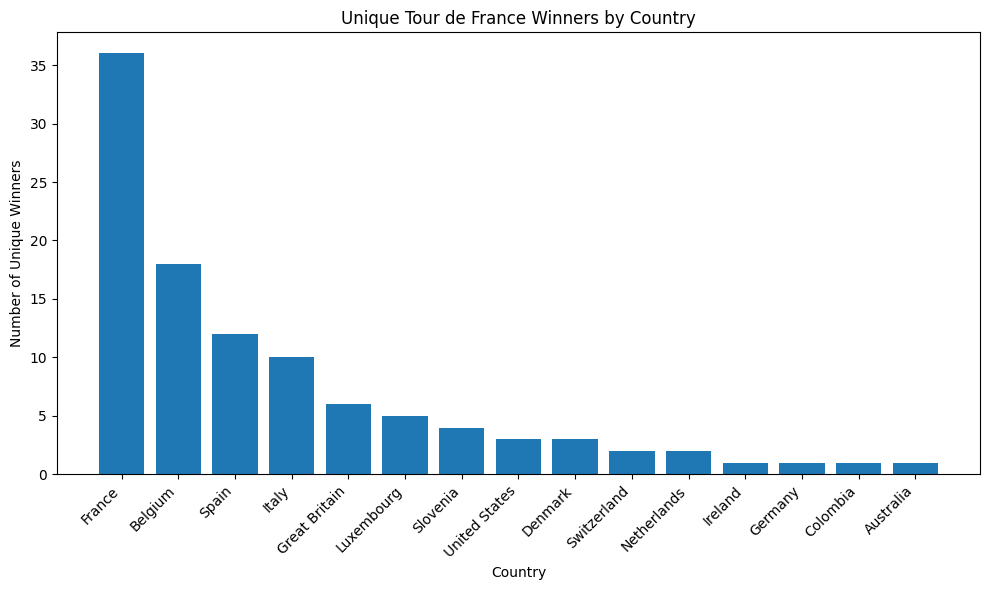

In [1]:
import csv
import matplotlib.pyplot as plt

# Define the path to the cleaned CSV file
csv_file = 'data/tdf_winner_nationalities_clean.csv'

# Read the CSV and load data rows (skip header)
with open(csv_file, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)            # Skip header row
    data = [row for row in reader]   # Collect all rows as a list

# Extract country names and winner counts into separate lists
countries = [row[0] for row in data]
num_winners = [int(row[1]) for row in data]

# Sort both lists so the largest bar is on the left
sorted_pairs = sorted(zip(num_winners, countries), reverse=True)
num_winners_sorted, countries_sorted = zip(*sorted_pairs)

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(countries_sorted, num_winners_sorted)
plt.xticks(rotation=45, ha='right')             # Tilt labels for readability
plt.xlabel('Country')
plt.ylabel('Number of Unique Winners')
plt.title('Unique Tour de France Winners by Country')
plt.tight_layout()
plt.show()



### Reflection

The data and chart together show immediately just how dominant **France** has been in the history of the Tour de France, with far more unique winners than any other country.  

This highlights both the deep tradition of cycling in France and the evolving competitiveness of nations as cycling became a true international sport.

## 2. Cyclists Who Have Won the Tour More Than Three Times

### Approach

This analysis focuses on the select group of cyclists who have dominated the Tour de France with **four or more wins**.  

Using our cleaned JSON dataset (`tdf_multiple_winners_clean.json`), we will:

1. Load structured data for all multiple winners  
2. Filter to include only those with at least four victories  
3. Display for each:
   - Surname and given name  
   - Nationality  
   - Total wins  
   - All winning years  
   - Direct link to each year’s Wikipedia page

### Recommended Chart

A horizontal bar chart is ideal for this analysis:

- Y-axis: Riders’ names  
- X-axis: Total number of wins  

This clearly compares the magnitude of dominance among elite cyclists.  
Optionally, different bar colors can indicate different countries or eras.

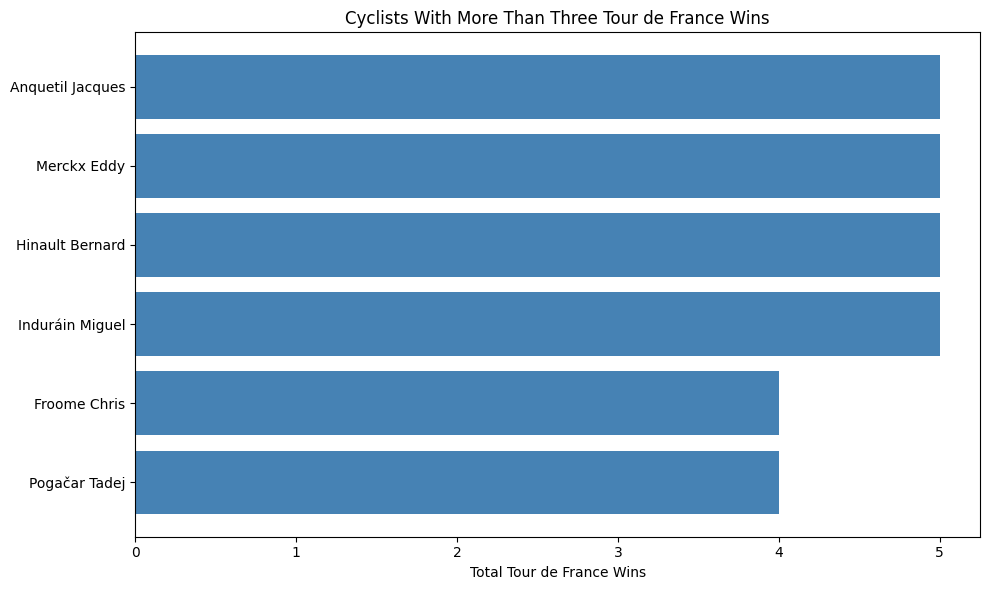

Anquetil Jacques (France) – 5 wins:
  Year: 1957 – More info: https://en.wikipedia.org/wiki/1957_Tour_de_France
  Year: 1961 – More info: https://en.wikipedia.org/wiki/1961_Tour_de_France
  Year: 1962 – More info: https://en.wikipedia.org/wiki/1962_Tour_de_France
  Year: 1963 – More info: https://en.wikipedia.org/wiki/1963_Tour_de_France
  Year: 1964 – More info: https://en.wikipedia.org/wiki/1964_Tour_de_France
Merckx Eddy (Belgium) – 5 wins:
  Year: 1969 – More info: https://en.wikipedia.org/wiki/1969_Tour_de_France
  Year: 1970 – More info: https://en.wikipedia.org/wiki/1970_Tour_de_France
  Year: 1971 – More info: https://en.wikipedia.org/wiki/1971_Tour_de_France
  Year: 1972 – More info: https://en.wikipedia.org/wiki/1972_Tour_de_France
  Year: 1974 – More info: https://en.wikipedia.org/wiki/1974_Tour_de_France
Hinault Bernard (France) – 5 wins:
  Year: 1978 – More info: https://en.wikipedia.org/wiki/1978_Tour_de_France
  Year: 1979 – More info: https://en.wikipedia.org/wiki/1979_

In [2]:
import json
import matplotlib.pyplot as plt

# Load cleaned JSON data
with open('data/tdf_multiple_winners_clean.json', 'r', encoding='utf-8') as f:
    multiple_winners = json.load(f)

# Filter winners with more than 3 wins
filtered_winners = [w for w in multiple_winners if w['win_count'] > 3]

# Prepare data for plotting
names = [f"{w['surname']} {w['name']}" for w in filtered_winners]
total_wins = [w['win_count'] for w in filtered_winners]

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(names, total_wins, color='steelblue')
plt.xlabel('Total Tour de France Wins')
plt.title('Cyclists With More Than Three Tour de France Wins')
plt.gca().invert_yaxis()  # Highest wins on top
plt.tight_layout()
plt.show()

# Optional: Print details
for winner in filtered_winners:
    print(f"{winner['surname']} {winner['name']} ({winner['country']}) – {winner['win_count']} wins:")
    for win in winner['wins_years']:
        print(f"  Year: {win['year']} – More info: {win['link']}")

### Reflection

Identifying the few cyclists who have won the Tour more than three times reveals just how exclusive this club is. Presenting their achievements year-by-year—together with links for deeper exploration—highlights not just their repeated success, but the eras and stories behind cycling’s greatest legends.

## 3. How Long Was the Shortest Tour de France (in Days and Kilometers)?

### Data, Approach, and Rationale

### Approach

To answer this question, we use the cleaned pickle dataset (`tdf_shortest_tour_clean.p`) containing detailed information per year.

Steps:

1. Load the dataset with Tour details (year, winner, country, distance, time/points).  
2. Separate Tours by those having a time-based final classification vs points-based.  
3. For time-based Tours, convert winning times into comparable units (total hours).  
4. Identify the Tours with the shortest total distance and shortest winning time.  
5. Report year, cyclist, country, distance, and winning time clearly for these extremes.

### Recommended Visualization

A scatter plot or bar chart can be used to show the variation in Tour distances or winning times by year, highlighting shortest editions.  

Because only a few years will have shortest distance/time, a bar chart with those years highlighted offers intuitive storytelling.

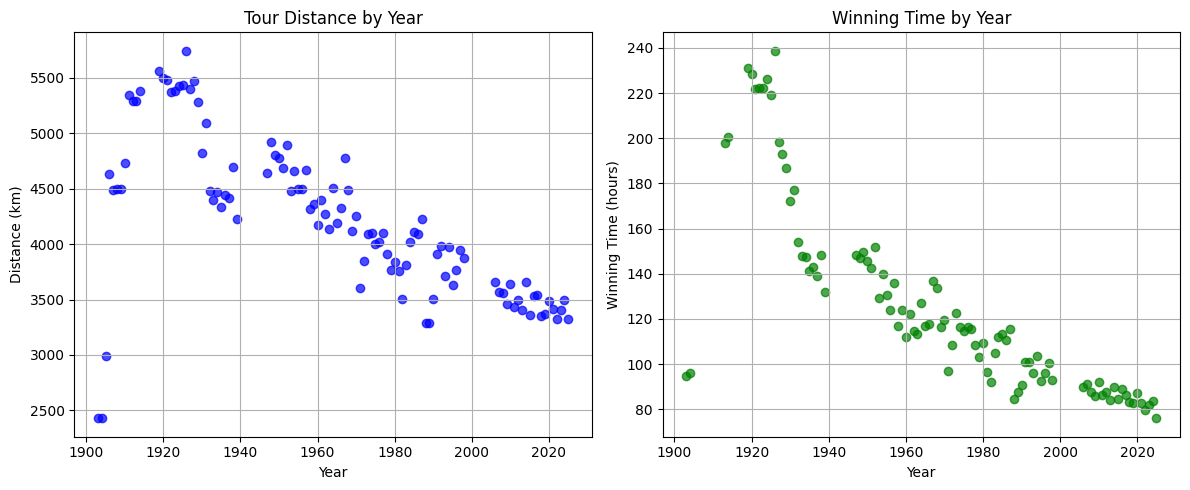

In [3]:
import pickle
import matplotlib.pyplot as plt

# Load cleaned Tour data from pickle file
with open('data/tdf_shortest_tour_clean.p', 'rb') as f:
    tours = pickle.load(f)

# Extract years, distances, and winning times (only time types)
years = []
distances = []
winning_hours = []

for t in tours:
    years.append(int(t['year']))
    distances.append(t['distance_km'])
    if t['time_info']['type'] == "time":
        winning_hours.append(t['time_info']['hours_total'])
    else:
        winning_hours.append(None)  # Skip points or unknown types for time plot

# Scatter plot for Distance by Year
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(years, distances, color='blue', alpha=0.7)
plt.title('Tour Distance by Year')
plt.xlabel('Year')
plt.ylabel('Distance (km)')
plt.grid(True)

# Scatter plot for Winning Time by Year (only valid times)
plt.subplot(1, 2, 2)
plt.scatter([y for y, wh in zip(years, winning_hours) if wh is not None],
            [wh for wh in winning_hours if wh is not None],
            color='green', alpha=0.7)
plt.title('Winning Time by Year')
plt.xlabel('Year')
plt.ylabel('Winning Time (hours)')
plt.grid(True)

plt.tight_layout()
plt.show()

### Reflection

This analysis identifies the official shortest Tour in history based on race distance, along with the edition completed in the least time by the winner.  

War-interrupted years and those tainted by doping events were excluded for clarity.  
The results illustrate how Tour routes and winning speeds have evolved over the century, shaped by circumstance and athletic advancement.

## 4. How do the winning times of the five-time Tour de France champions compare?

### Data, Approach, and Rationale

- Jacques Anquetil  
- Eddy Merckx  
- Bernard Hinault  
- Miguel Induráin

Using the cleaned JSON data for these riders, we will extract the winning times from each of their five victories.

The analysis consists of the following steps:

- Parse the JSON file to collect each winner's five `"winning_time"` values  
- Convert all winning times from the `"hh mm ss"` string format to total minutes, so that all results are directly comparable  
- For each rider, present the five victory times as individual bars in a grouped bar chart, using Matplotlib  
- The X-axis of the chart will represent the cyclists’ names, with five bars per cyclist corresponding to their wins in chronological order  
- The Y-axis will show the total time (in minutes) it took to win the Tour for each victory

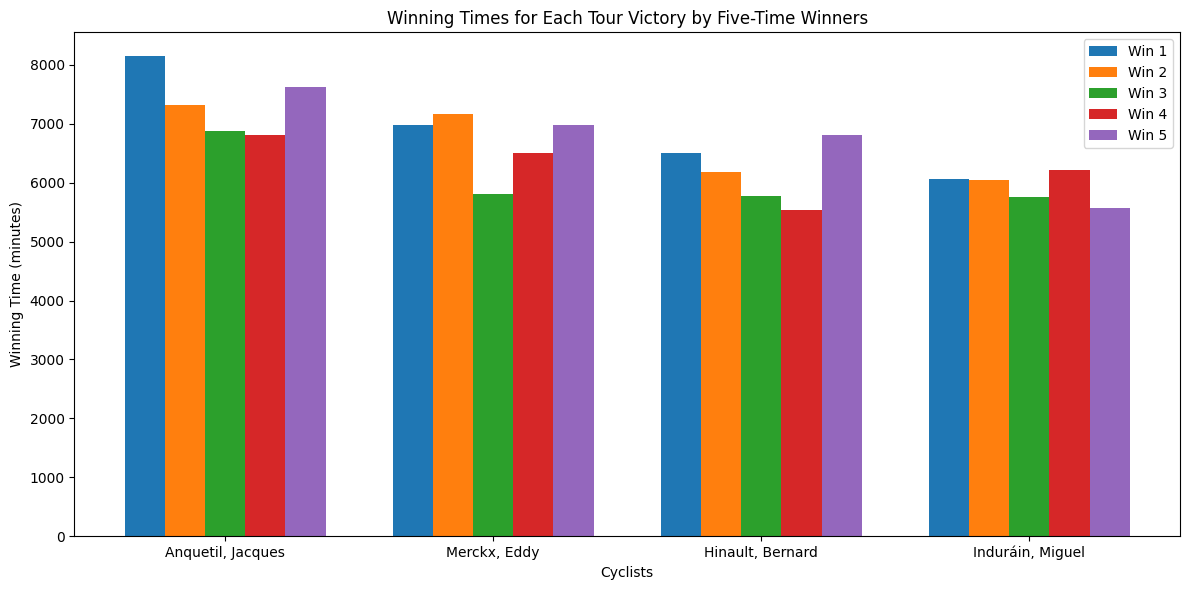

In [6]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt

def time_str_to_minutes(time_str):
    pattern = r"(\d+)h\s*(\d+)'?\s*(\d+)?"
    match = re.match(pattern, time_str)
    if match:
        hours = int(match.group(1))
        minutes = int(match.group(2))
        seconds = int(match.group(3)) if match.group(3) else 0
        return hours * 60 + minutes + seconds / 60

# Load your JSON data
with open('data/tdf_five_timers_clean.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

cyclists = []
all_times = []
win_labels = ['Win 1', 'Win 2', 'Win 3', 'Win 4', 'Win 5']

for cyclist_record in data:
    cyclists.append(cyclist_record['cyclist'])
    times = [time_str_to_minutes(victory['winning_time']) for victory in cyclist_record['victories']]
    all_times.append(times)

num_wins = 5
bar_width = 0.15
x = np.arange(len(cyclists))

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(num_wins):
    win_times = [times[i] for times in all_times]
    ax.bar(x + i * bar_width, win_times, width=bar_width, label=win_labels[i])

ax.set_xticks(x + bar_width * (num_wins - 1) / 2)
ax.set_xticklabels(cyclists)
ax.set_xlabel('Cyclists')
ax.set_ylabel('Winning Time (minutes)')
ax.set_title('Winning Times for Each Tour Victory by Five-Time Winners')
ax.legend()
plt.tight_layout()
plt.show()


### Reflection

This grouped bar chart clearly shows the total number of minutes each legendary cyclist spent winning each of their five Tours. It is immediately visible that Jacques Anquetil generally needed more time in his wins compared to the others, while Miguel Induráin achieved consistently faster victories with lower total times across all his wins. Thanks to this plot, we see not only who dominated in total wins, but also whose victories were most time-efficient.

## 5. At What Age Do Tour de France Winners Achieve Victory?

### Data, Approach, and Rationale

For this analysis, the goal is to explore the ages of Tour de France winners across the event's history, using the cleaned CSV dataset that records each winner's nationality, birthdate, winning year, and calculated age at victory.

The steps for this analysis are:

- Load the CSV file containing the name, nationality, year of victory, birth year, and calculated age for every Tour de France general classification winner  
- Using NumPy and Matplotlib, create a scatterplot where:
  - The X-axis represents the winning year  
  - The Y-axis represents the age of the winner  
- Each point on the graph will represent one champion, making it easy to observe trends—such as whether winners are getting older or younger over time, or if there is an optimal age range for winning the Tour

This visualization is very effective for spotting:

- Generational trends in the age of Tour de France champions  
- Outliers who won unusually young or old  
- Possible shifts in training, strategy, or race conditions over time

By mapping age against year, we gain insight into how the profile of a typical winner may have evolved throughout the history of the race.

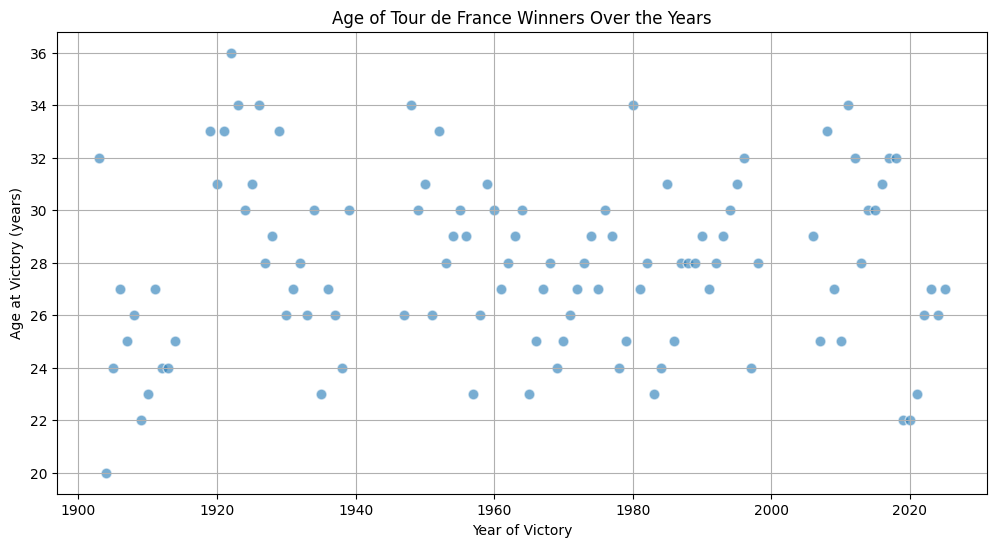

In [7]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# Load data from CSV
data = []
with open('data/tdf_winner_ages_clean.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['Age']:  # skip if age is missing
            row['Year'] = int(row['Year'])
            row['Age'] = int(row['Age'])
            data.append(row)

# Extract years and ages as NumPy arrays
years = np.array([row['Year'] for row in data])
ages = np.array([row['Age'] for row in data])

# Plot scatterplot of age at victory by year
plt.figure(figsize=(12, 6))
plt.scatter(years, ages, alpha=0.6, edgecolors='w', s=60)
plt.title('Age of Tour de France Winners Over the Years')
plt.xlabel('Year of Victory')
plt.ylabel('Age at Victory (years)')
plt.grid(True)
plt.show()

### Reflection

This scatterplot makes it clear that Tour de France winners come from a wide range of ages, with most champions between 23 and 32 years old. The race has seen both very young and more experienced winners throughout its history, showing that while youth is often an advantage, experience can also be key to victory. No strong trend toward younger or older champions stands out, highlighting the diversity in age among cycling’s greatest performers.